In [44]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path(os.getenv("IDX_DATA_DIR", "data"))

In [46]:
files = sorted((p for p in (DATA_DIR / "raw/csv").glob("CRMLSSold*.csv")),
    reverse=True,
)

Visualizing Distribution of Closing Prices in 08/2025

Distribution is right skewed and unimodal.

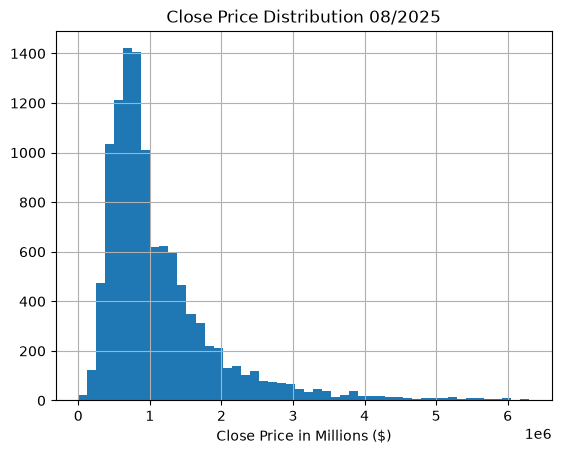

Mean: 1237614.4415994412
Median: 885500.0
Standard Deviation: 1377136.8848245647


In [ ]:
df = pd.read_csv(DATA_DIR / "raw/csv/CRMLSSold202508.csv")
df = df[(df["PropertyType"] == "Residential") & (df["PropertySubType"] == "SingleFamilyResidence")]
ClosePrice = df["ClosePrice"]

ClosePrice.hist(bins=50, range=(0, ClosePrice.quantile(0.99)))
plt.title("Close Price Distribution 08/2025")
plt.xlabel("Close Price in Millions ($)")
plt.show()

mean = ClosePrice.mean()
median = ClosePrice.median()
std = ClosePrice.std()

print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Standard Deviation: {std}")

Closing price distribution across all reported time periods (02/2024-04/2026)

Very similar distribution to the single period, boxplots show that all the time periods have similar distributions with moderate variation.

In [48]:
cols = ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]
all_sales = pd.concat(
    [pd.read_csv(f, usecols=cols + ["PropertyType", "PropertySubType"]).assign(month=f.name[9:15]) for f in files],
    ignore_index=True,
)
all_sales = all_sales[(all_sales["PropertyType"] == "Residential") & (all_sales["PropertySubType"] == "SingleFamilyResidence")]

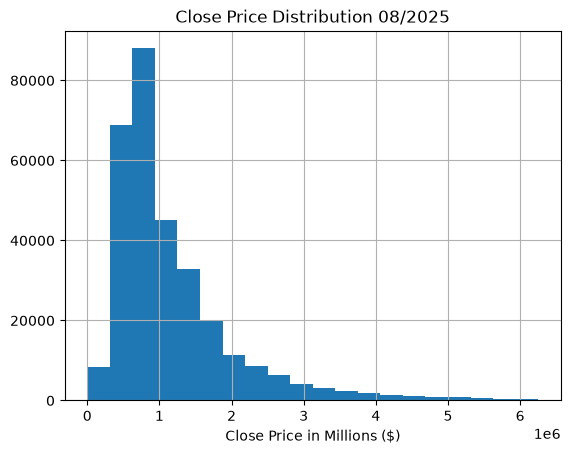

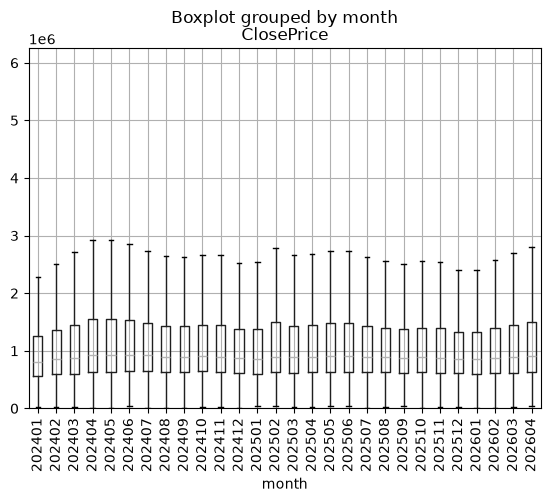

In [56]:
all_sales["ClosePrice"].hist(bins=20, range=(0, all_sales["ClosePrice"].quantile(0.99)))
plt.title("Close Price Distribution 08/2025")
plt.xlabel("Close Price in Millions ($)")
plt.show()

all_sales.boxplot("ClosePrice", by="month", showfliers=False, rot=90)
plt.ylim(0, all_sales["ClosePrice"].quantile(0.99))
plt.show()

Living area, bedrooms, bathrooms, and lot size distributions across all reported time periods

Overall, between all the time periods there is pretty much no variation in distributions for any of these variables meaning that the types of houses being sold remain the same. 



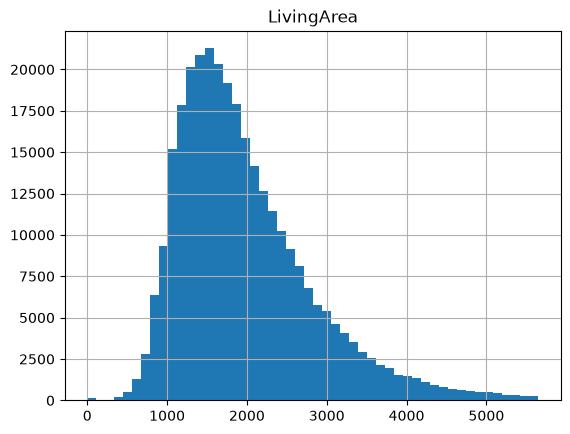

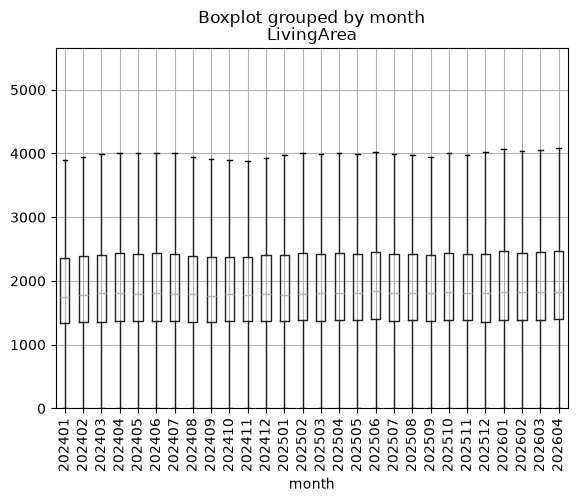

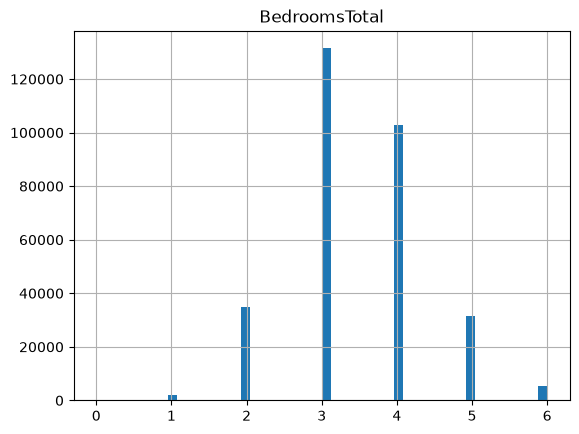

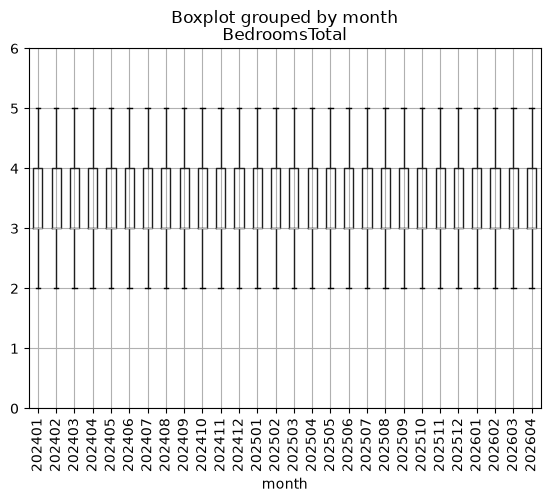

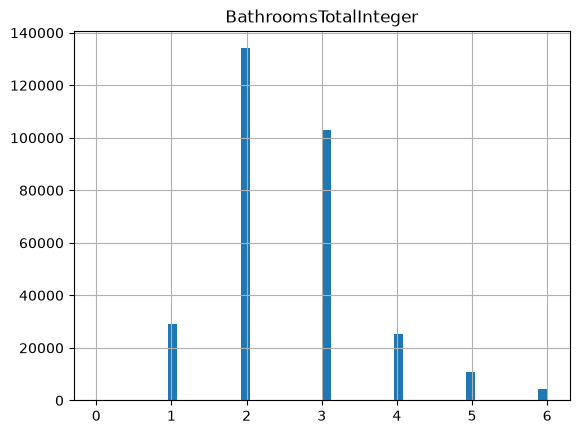

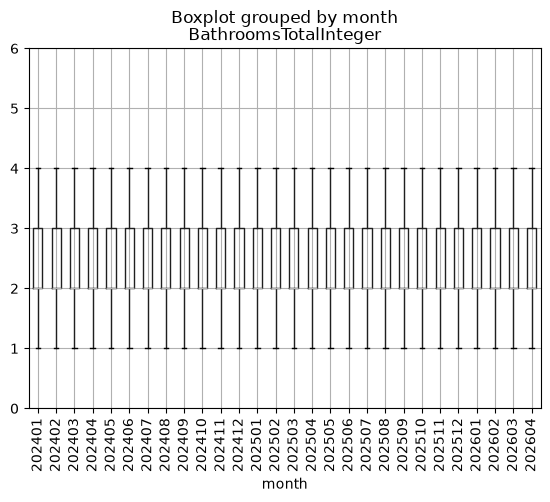

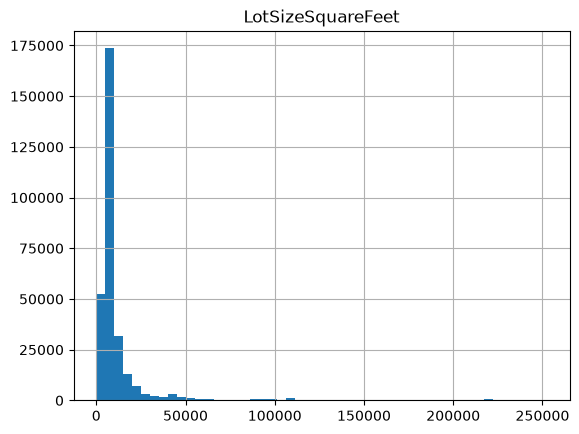

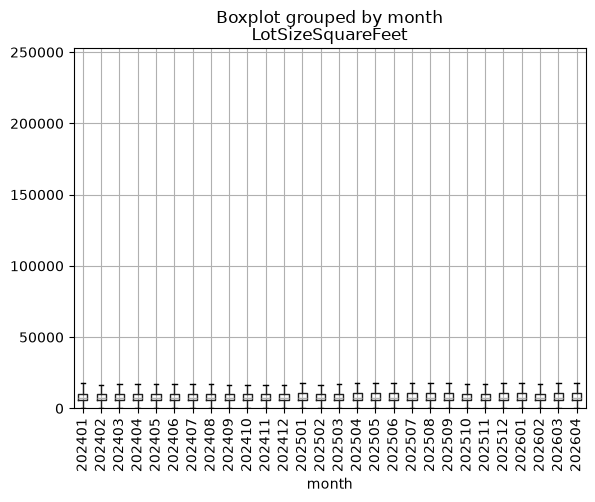

In [64]:
for col in ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]:
    cap = all_sales[col].quantile(0.99)
    all_sales[col].hist(bins=50, range=(0, cap))
    plt.title(col)
    plt.show()
    all_sales.boxplot(col, by="month", showfliers=False, rot=90)
    plt.ylim(0, cap)
    plt.show()

Close price vs living area, bedrooms, bathrooms, and lot size. Used random sample of n = 20k across all time periods 

Close price vs living area has a moderately positive association 
Close price vs Bedroom & Bathroom both have positive association but Bathroom is much stronger 
Close price vs lot size has no discernable association

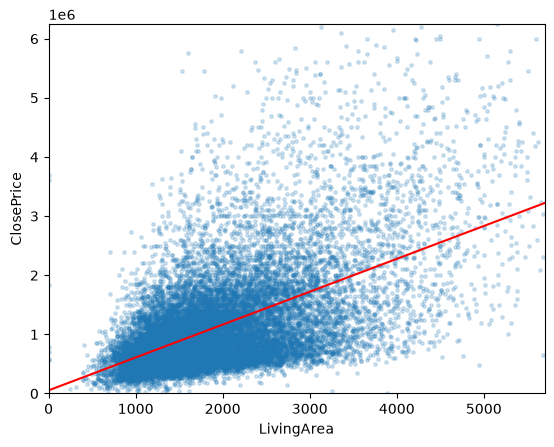

r = 0.5552538073178869


In [70]:
import numpy as np

sample = all_sales.sample(20000, random_state=0)
x_cap = sample["LivingArea"].quantile(0.99)
y_cap = sample["ClosePrice"].quantile(0.99)
plot = sample[(sample["LivingArea"] <= x_cap) & (sample["ClosePrice"] <= y_cap)].dropna(subset=["LivingArea", "ClosePrice"])

x = plot["LivingArea"]
y = plot["ClosePrice"]
m, b = np.polyfit(x, y, 1)
r = x.corr(y)

plt.scatter(x, y, s=6, alpha=0.2)
plt.plot([0, x_cap], [b, m * x_cap + b], color="red")
plt.xlim(0, x_cap)
plt.ylim(0, y_cap)
plt.xlabel("LivingArea")
plt.ylabel("ClosePrice")
plt.show()
print(f"r = {r}")

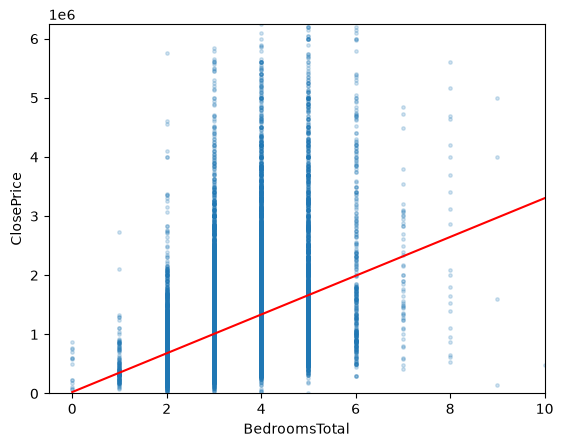

r = 0.35507326576478065


In [82]:
plot = sample[(sample["BedroomsTotal"] <= 10) & (sample["ClosePrice"] <= y_cap)].dropna(subset=["BedroomsTotal", "ClosePrice"])
x = plot["BedroomsTotal"]
y = plot["ClosePrice"]
m, b = np.polyfit(x, y, 1)
r = x.corr(y)

plt.scatter(x, y, s=6, alpha=0.2)
plt.plot([0, 10], [b, m * 10 + b], color="red")
plt.xlim(-0.5, 10)
plt.ylim(0, y_cap)
plt.xlabel("BedroomsTotal")
plt.ylabel("ClosePrice")
plt.show()
print(f"r = {r}")

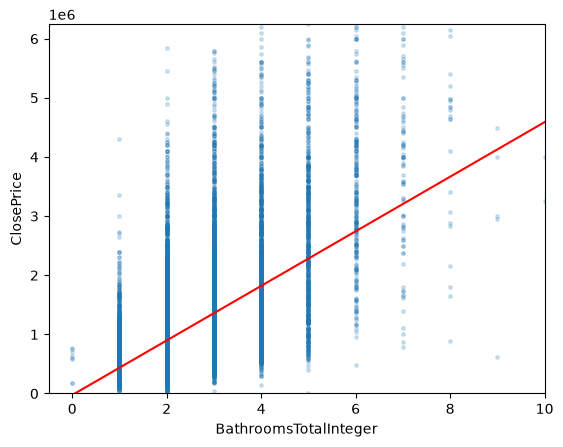

r = 0.551646875712404


In [80]:
plot = sample[(sample["BathroomsTotalInteger"] <= 10) & (sample["ClosePrice"] <= y_cap)].dropna(subset=["BathroomsTotalInteger", "ClosePrice"])
x = plot["BathroomsTotalInteger"]
y = plot["ClosePrice"]
m, b = np.polyfit(x, y, 1)
r = x.corr(y)

plt.scatter(x, y, s=6, alpha=0.2)
plt.plot([0, 10], [b, m * 10 + b], color="red")
plt.xlim(-0.5, 10)
plt.ylim(0, y_cap)
plt.xlabel("BathroomsTotalInteger")
plt.ylabel("ClosePrice")
plt.show()
print(f"r = {r}")

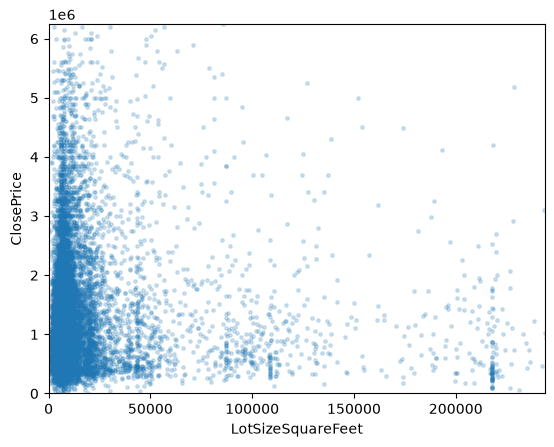

In [68]:
plt.scatter(sample["LotSizeSquareFeet"], sample["ClosePrice"], s=6, alpha=0.2)
plt.xlim(0, sample["LotSizeSquareFeet"].quantile(0.99))
plt.ylim(0, y_cap)
plt.xlabel("LotSizeSquareFeet")
plt.ylabel("ClosePrice")
plt.show()

Correlation (r) heatmap of close price and house features using sa

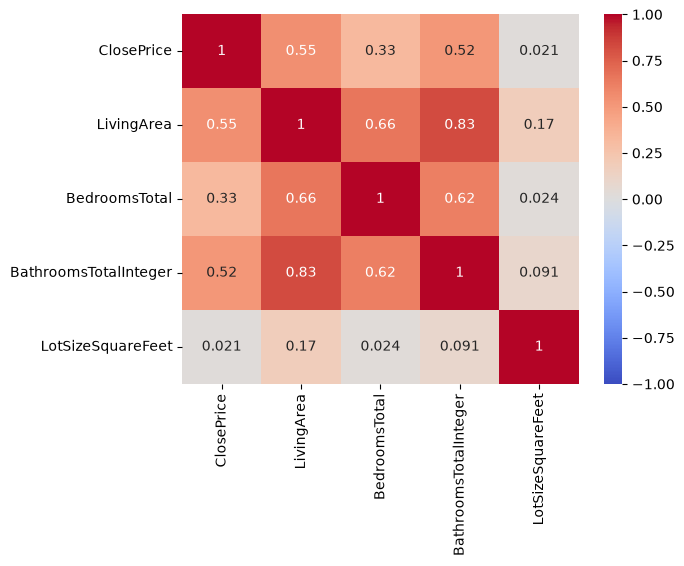

In [85]:
import seaborn as sns

heat = sample[cols]
heat = heat[(heat <= heat.quantile(0.99)).all(axis=1)]
sns.heatmap(heat.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()